In [1]:
# from lib import epl 
# from lib import OSN
# from lib import readout
from lib import plots

from Dennler_lib.epl import EPL 
from Dennler_lib.OSN import OSN_encoding
from Dennler_lib.readout import readout
#from Dennler_lib import plots
from my_lib import my_plots
from my_lib import my_readout

import numpy as np
import pickle 
import time
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
#import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning
from sklearn.decomposition import PCA

LOAD AND GENERATE DATA


In [3]:
# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits() #refer to when plotting

# project the 64-dimensional data to a lower dimension
pca = PCA(n_components=64, whiten=False)
pca.fit(digits.data) #refer to whe
#may use digits.data

images = digits.images
c_images = pca.transform(digits.data) #I changed from digits.images to digits.data

#compare with c_images = digits.data

#from 2 by 2 to 1d arrays (if 2 by 2)
targets = digits.target #need to reshape images and targets
#may need to make c_images into an array

# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, c_images):
    image_dict[t].append(img)

In [4]:

numPatterns = 6
#randomly choose 6 digits
digits = np.array([0, 2, 4, 5, 7, 9], ndmin = 2)


In [5]:
#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        #print(training_image)
        training_image = np.ndarray.astype(training_image, int)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        #print(training_image)
        train_data.append(training_image)
    return train_data

In [6]:
# generate the training data
digitss = [0, 2, 4, 5, 7, 9]
train_data = np.array(get_training_data(digits=digitss));

In [7]:
def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData
numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))

# plot train_data and test_data

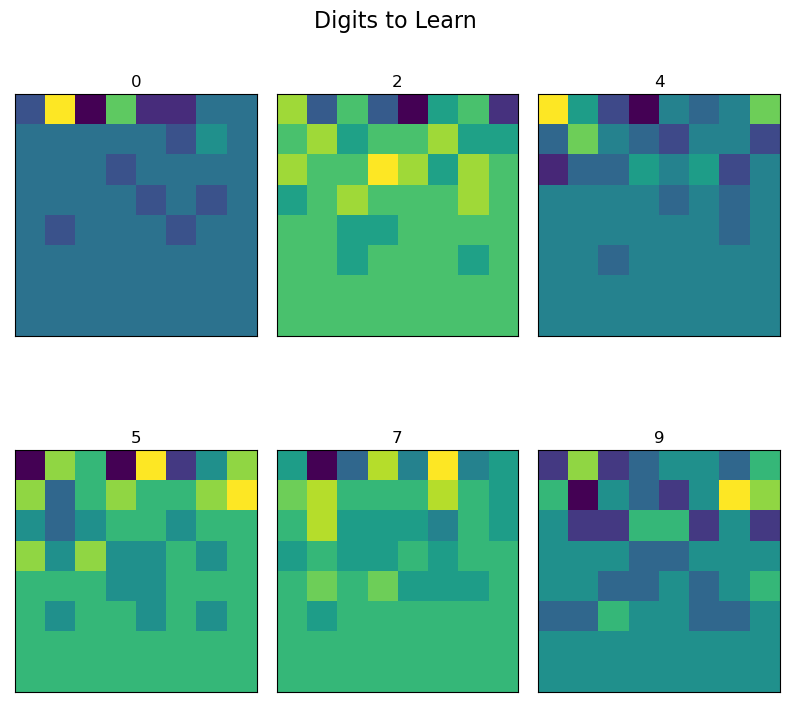

In [22]:
# Train Data
pre.plot_images(digitss, train_data, title="Digits to Learn");


In [26]:
test_digitss

array([0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 7, 7,
       7, 7, 7, 9, 9, 9, 9, 9])

In [28]:
digitss

[0, 2, 4, 5, 7, 9]

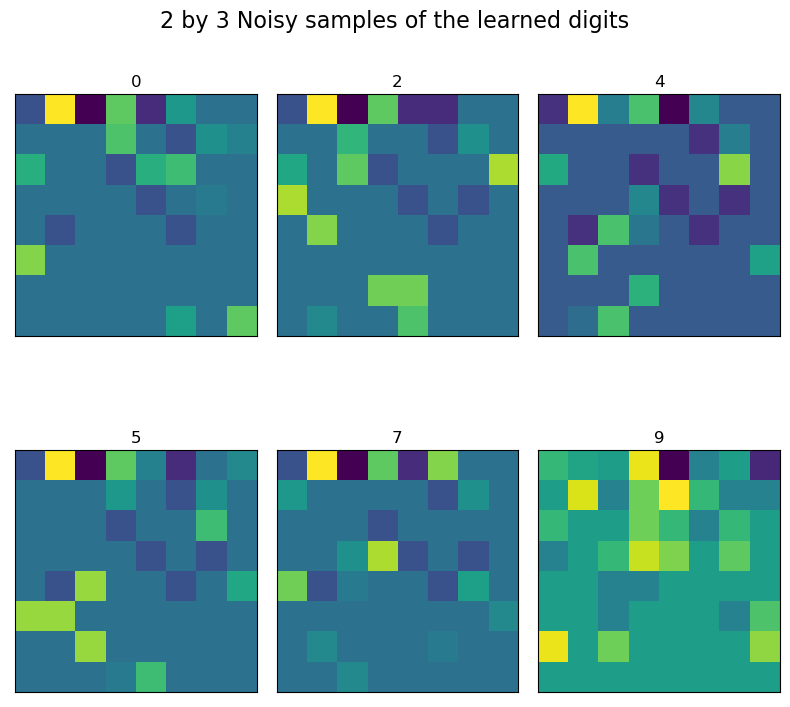

In [29]:
#Test Data: can have 10 rows instead of 2 to show all of test_data
test_digits = repmat(digitss, numTestSamples,1).T.reshape((1,-1))
test_digitss = repmat(digits, numTestSamples,1).T.flatten()
#pre.plot_images(test_digitss, test_data, title="10 by 3 Noisy samples of the learned digits",nrows=10, ncols=3);
pre.plot_images(digitss, test_data, title="2 by 3 Noisy samples of the learned digits",nrows=2, ncols=3)

# scaling and defining trainingOdors and testOdors

In [10]:
scale = 15.0
trainingOdors, testOdors = pre.rescaleInputBoth(train_data,test_data,scale)

In [20]:
[trainingOdors.min(), trainingOdors.max(), testOdors.min(), testOdors.max()]

[0, 15, 0, 15]

## training and testing

In [11]:
nGamma = 5
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
nGammaPerOdor = 5
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 
    
#Training (Dennler's)
t0 = time.time() 
for i in range(0, len(trainingOdors)):
    # print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1)
    epl.GClayer.invokeNeurogenesis()
    sniff(trainingOdors[i], learn_flag=0)
t1 = time.time()

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
    # if((i+1)%10==0 and (i+1)!=0):
    #     print(str(i+1) + " odors tested"); 
t2 = time.time(); 
sim_time = t2-t1
print("Simulation Duration = " + str(sim_time) + "s")


Number of odors to train = 6
Number of odors to test = 30
Simulation Duration = 125.49294424057007s


In [12]:
print("Learned gamma indices:", [i * (nGammaPerOdor + 5) - 1 for i in range(1, nOdors + 1)])
sMatrix = readout(epl.gammaCode, nOdors, nTestPerOdor)
print("Length of similarity matrix:", len(sMatrix))
print("Shape of first row:", len(sMatrix[0]) if len(sMatrix) > 0 else 'Empty')

Learned gamma indices: [9, 19, 29, 39, 49, 59]
Length of similarity matrix: 150
Shape of first row: 6


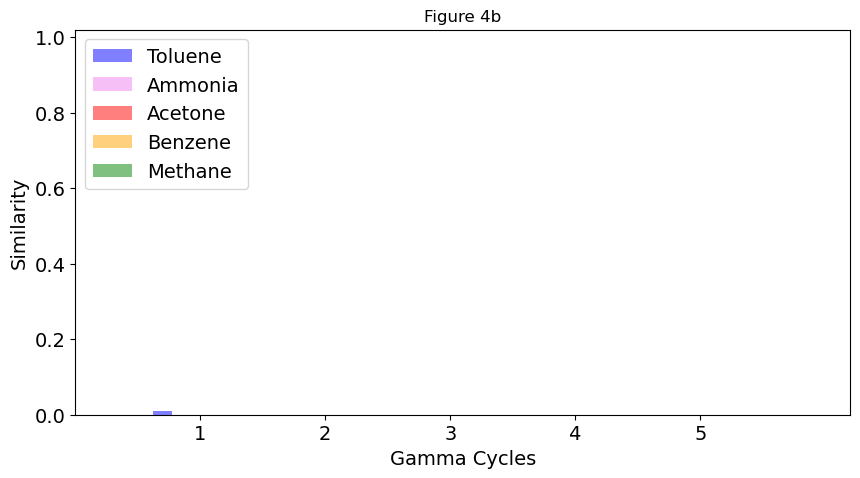

In [31]:
from lib import plots
plots.plotFigure4b(sMatrix)

In [32]:
def plotFigure4d_images(gammaCode, sMatrix):
    fig, axs = plt.subplots(figsize=(18, 9))
    fig.suptitle("Figure 4d - Images of Digits", fontsize=16)

    # Use digits you have
    imageDigits = [0, 2, 4, 5, 7, 9]
    nOdors = len(imageDigits)
    plotTitles = [f"Digit {d}" for d in imageDigits]

    # Adjust plotting order if needed
    rasterOrderOdors = list(range(nOdors))
    sampleNumbers = [0] * nOdors  # default

    nMCs = len(gammaCode[0])
    nGamma = 5
    nTestPerOdor = int(len(sMatrix) / (nOdors * nGamma))

    plt.subplots_adjust(hspace=0.45, wspace=0.25)
    fsize = 12
    fsize2 = 16

    for i in range(nOdors):
        # Raster plot
        plt.subplot(3, 4, 2 * i + 1)
        odorID = rasterOrderOdors[i]
        digit = imageDigits[odorID]

        sniffID = nOdors * 2 + nTestPerOdor * odorID + sampleNumbers[odorID]

        for j in range(nGamma):
            gammaID = int(nGamma * sniffID + j)
            for k in range(nMCs):
                if gammaCode[gammaID][k] != 0:
                    spikeTime = 20 - gammaCode[gammaID][k] + 40 * j
                    plt.scatter(spikeTime, k, color='k', s=2)
        plt.title(plotTitles[i], fontsize=fsize2)
        plt.yticks([0, 20, 40, 60], fontsize=fsize)
        if i >= (nOdors - 2):
            plt.xticks([0, 40, 80, 120, 160, 200], fontsize=fsize)
            plt.xlabel('Timesteps', fontsize=fsize2)
            plt.ylabel('MC Index', fontsize=fsize2)
        else:
            plt.xticks([])

        # Similarity plot
        plt.subplot(3, 4, 2 * i + 2)
        bar_y = []
        gammaID = odorID * nTestPerOdor * nGamma + sampleNumbers[odorID] * nGamma
        for j in range(5):
            bar_y.append(sMatrix[int(gammaID + j)][odorID])
        plt.bar([40, 80, 120, 160, 200], bar_y, color='black', width=10.0)
        plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], fontsize=fsize)
        plt.ylim([0.0, 1.02])
        plt.xlim([0, 240])
        if i >= (nOdors - 2):
            plt.xticks([40, 80, 120, 160, 200], [1, 2, 3, 4, 5], fontsize=fsize)
            plt.xlabel('Gamma Cycles', fontsize=fsize2)
            plt.ylabel('Similarity', fontsize=fsize2)
        else:
            plt.xticks([])
    plt.show()


def plotFigure4b_images(sMatrix): 
    bar1_x, bar2_x, bar3_x, bar4_x, bar5_x = [], [], [], [], [];      
    bar1_y, bar2_y, bar3_y, bar4_y, bar5_y = [], [], [], [], [];      
    nGamma = 5; 
    testOdorID = 0;              #sniff ID of test odor 
    for i in range(0, nGamma):
        bar1_y.append(sMatrix[testOdorID+i][0]);
        bar2_y.append(sMatrix[testOdorID+i][1]);
        bar3_y.append(sMatrix[testOdorID+i][2]);
        bar4_y.append(sMatrix[testOdorID+i][3]);
        bar5_y.append(sMatrix[testOdorID+i][4]);
        
    w = 0.15        #width of bars
    fsize = 14;
    xticks = []
    xtick_labels = []
    for i in range(0, 5):    
        bar1_x.append(i-2*w);
        bar2_x.append(i-w);
        bar3_x.append(i);
        bar4_x.append(i+w); 
        bar5_x.append(i+2*w);     
        xticks.append(i)
        xtick_labels.append(str(i+1))
    plt.figure(2, figsize=(10, 5))
    fig = plt.subplot(111)
    opacity = 0.5; 
    bar1 = plt.bar(bar1_x, bar1_y, width = w, color = 'blue', alpha = opacity, align='center')
    bar2 = plt.bar(bar2_x, bar2_y, width = w, color = 'violet', alpha = opacity, align='center')
    bar3 = plt.bar(bar3_x, bar3_y, width = w, color = 'red', alpha = opacity, align='center')
    bar4 = plt.bar(bar4_x, bar4_y, width = w, color = 'orange', alpha=opacity, align='center')
    bar5 = plt.bar(bar5_x, bar5_y, width = w, color = 'green', alpha=opacity, align='center')
    plt.xlim(-1, len(bar1_x)+0.2)
    plt.ylim(0, 1.02)
    plt.xticks(xticks, xtick_labels, fontsize=fsize)
    plt.yticks(fontsize=fsize); 
    fig.legend( (bar1, bar2, bar3, bar4, bar5), ('0', '2','4','5','7','9'), loc = 'upper left', fontsize=fsize)
    plt.ylabel('Similarity', fontsize=fsize); 
    plt.xlabel('Gamma Cycles', fontsize=fsize); 
    plt.title("Figure 4b")
    plt.show()

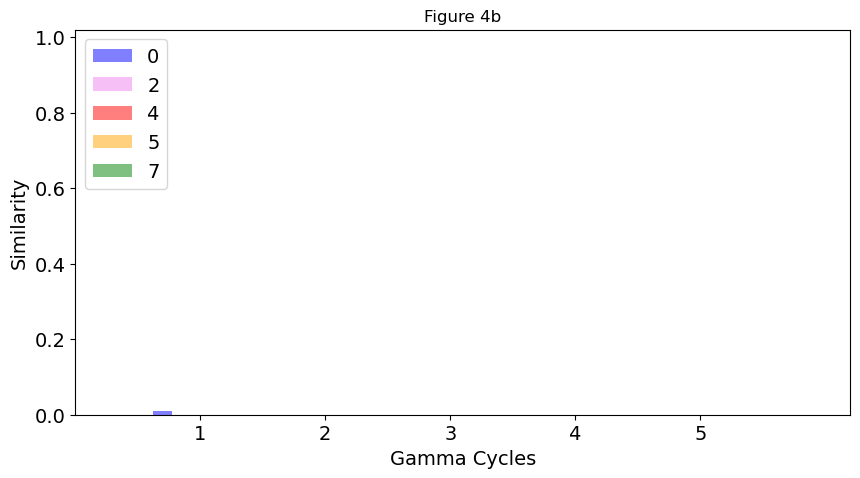

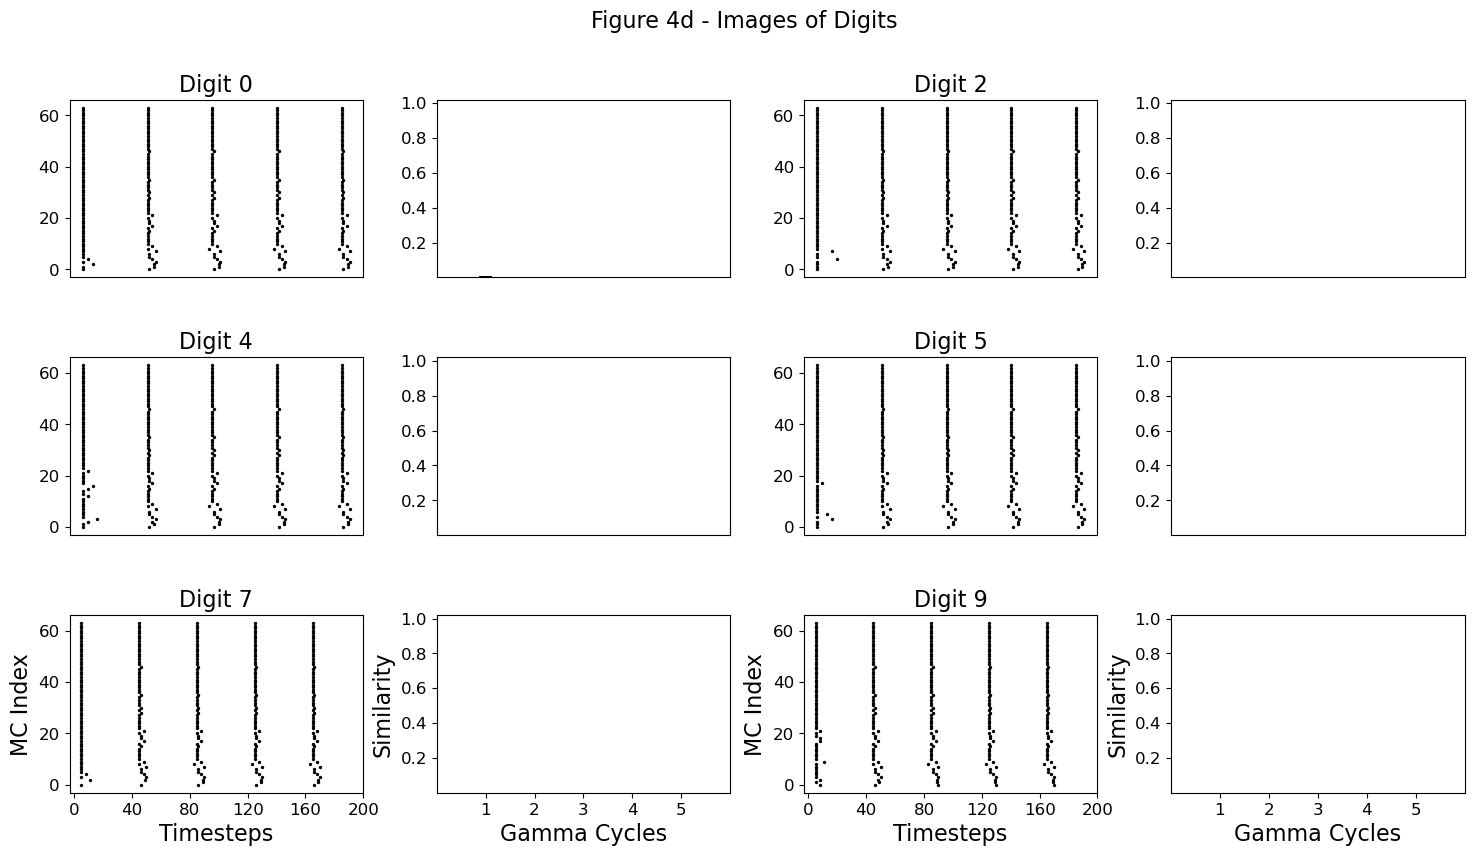

In [33]:
#Plots
plotFigure4b_images(sMatrix); 
plotFigure4d_images(epl.gammaCode, sMatrix); 

## epl gammaCode parsing


In [15]:
nGammaPerOdor_training = 10
#Remember the first training loop uses nGammaPerOdor = 10
#The added 5 refers to the second loop of training which uses the default variable in sniff for nGammaPerOdor
#The added len(testOdors) * 5 refers to the third testing loop which uses the dafault variable in sniff for nGammaPerOdor
# len(testOdors) = len(digits) * numTestSamples because generateTestOdors generates 5 noisy versions of each test digit
# this is in order of loops
gammaCode_size = len(trainingOdors)*(nGammaPerOdor_training + nGammaPerOdor) + digits.size* numTestSamples * nGammaPerOdor
#digits.size=len(trainingOdors) should have numTrainingSamples
#rename numTestSamples to numPerturbedSamples
(gammaCode_size,len(epl.gammaCode))

(240, 210)

In [16]:
numTestSamples

5

In [17]:
len(epl.gammaCode[0])

64

In [18]:
len(epl.gammaCode)

210

In [19]:
testOdors.shape

(30, 64)

In [ ]:
trainingOdors.shape

In [ ]:

trained = np.array(epl.gammaCode[len(trainingOdors)*10:len(trainingOdors)*15]).reshape(nGammaPerOdor, 6, -1)
tested = np.array(epl.gammaCode[len(trainingOdors)*15:]).reshape(nGammaPerOdor, 30, -1)

In [ ]:
trained[0][0]==trained[0][5]

In [ ]:
len(testOdors)/nGammaPerOdor

In [ ]:
trained.shape

In [ ]:
tested.shape #tested[-1]

In [ ]:
# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [ ]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((len(digits[0]), len(test_digits[0])), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (computeSimilarity(trained[-1][i], tested[-1][j]))
        
        """
        if SImatrix[i][j]> 0.75: #and test_digits[sim_index] == test_digits[i*5]: 
            true_positive+=1
        elif SImatrix[i][j]< 0.75: #and test_digits[sim_index] == test_digits[i*5]:
            false_negative+=1
        elif SImatrix[i][j] < 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            true_negative+=1
        elif SImatrix[i][j] > 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            false_positive+=1
        else:
            print("error")
#target recognition matrix to find what is above and below .75 
true_positive, true_negative, false_positive, false_negative
"""
decisionMatrix = (SImatrix> 0.75)

In [ ]:
SImatrix

In [ ]:
truthMatrix = np.equal(digits.T, test_digits)
truthMatrix.shape
#digits which is a 2d array, use reshape to 
#operations broadcasting when comparing two arrays of different dimensions

In [ ]:
#this is not decisionMatrix xor truthMatrix
#returns all the places where the decision is correct (trues are trues and falses re false)
#take a look at this logic
# Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
correct = ~(decisionMatrix ^ truthMatrix)

In [ ]:
correctID = np.count_nonzero(correct)
per_correct = float(correctID)/SImatrix.size

In [ ]:
(per_correct, sim_time)

In [ ]:
#repmat(digits, len(test_digits)-1)

In [ ]:
SImatrix.size

In [ ]:
epl.nMCs

In [ ]:
len(SImatrix), len(SImatrix[0])

In [ ]:
len(epl.gammaCode), len(epl.gammaCode[0])

In [ ]:
pre.plotFigure3b(epl.gammaCode, epl.nMCs, nGamma=5,figsize = (3,12))

In [ ]:
from my_lib import my_readout
sMatrix = my_readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
plotTitles= [0,2,4,5,7,9]
my_plots.learningBarFigure(sMatrix, plotTitles)
my_plots.rasterSimilarityPlot(epl.gammaCode, sMatrix, plotTitles, nMCs = epl.nMCs, nOdors = nOdors, nGamma = 5)

In [ ]:
import numpy as np
import time

class HashTableClassifier():
    def train(self, training_data):
        self.learned_odour_representations = {idx: odour for idx, odour in enumerate(training_data)}

    def denoise_test(self, testing_data):
        self.denoised_testing_data = {}
        for idx_test, testing_odour in enumerate(testing_data):
            best_matching, idx_best_matching = 0, None
            for idx_train, training_odour in self.learned_odour_representations.items():
                matches = sum(training_odour == testing_odour)
                if best_matching < matches:
                    best_matching, idx_best_matching = matches, idx_train
            self.denoised_testing_data[idx_test] = self.learned_odour_representations[idx_best_matching]

    def get_similarity_matrix(self):
        sMatrix = np.zeros((len(self.denoised_testing_data) * 5, len(self.learned_odour_representations)))
        for idx_test, testing_odour in self.denoised_testing_data.items():
            for idx_train, training_odour in self.learned_odour_representations.items():
                similarity = np.count_nonzero(training_odour == testing_odour) / 72
                for i in range(5):
                    sMatrix[5 * idx_test + i, idx_train] = similarity
        return sMatrix


def run_from_arrays(trainingOdors, testOdors):
    nOdors = len(trainingOdors)
    nTestPerOdor = len(testOdors) / nOdors
    print("Number of odors to train:", len(trainingOdors))
    print("Number of odors to test:", len(testOdors))

    # Initiate classifier
    hashtable_classifier = HashTableClassifier()

    # Run training
    t0 = time.time()
    hashtable_classifier.train(trainingOdors)
    t1 = time.time()

    # Run testing
    hashtable_classifier.denoise_test(testOdors)
    t2 = time.time()

    train_time = t1 - t0
    test_time = t2 - t1

    print("Training Duration total:", train_time, "s")
    print("Testing Duration total:", test_time, "s")

    # Extract similarity matrix
    sMatrix = hashtable_classifier.get_similarity_matrix()
    return sMatrix, hashtable_classifier.denoised_testing_data

sMatrix, denoised_data = run_from_arrays(trainingOdors, testOdors)
print(sMatrix.shape)  # Check the shape of the similarity matrix
plotFigure4b_images(sMatrix); 
plotFigure4d_images(epl.gammaCode, sMatrix); 